## Step 3.1 – Categorise the cause of each alert

Each SFDA alert has a free-text cause written by the manufacturer. To trend them, I sort each cause into one category using keyword rules.

- Rules are checked **in order**, and the first match wins. For example, "Not stated" is checked first, so an alert that only says "see attached FSN" isn't mislabelled.
- **Incorrect test result (IVD)** is checked early because it matters most for lab analysers and reagents. A wrong result can lead to a wrong diagnosis with no visible device failure.
- Anything the rules can't place stays **"Other"**. I don't force a category, so the share of "Other" is reported openly.
- This mirrors ISO 13485 clause 8.4 (analysis of data): turning raw complaint and alert text into categories that can be trended and acted on.

**Limitation:** keyword rules are a first pass, not a validated coding system such as the IMDRF adverse event terms. Some alerts could fit two categories but are counted once.

In [1]:
# 3.1 Load the clean file and categorise the cause of each alert
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, re
BASE  = '/content/drive/MyDrive/pms-saudi-safety-alerts'
CLEAN = f'{BASE}/data/clean'

alerts = pd.read_csv(f'{CLEAN}/alerts_clean.csv')
alerts['cause_en'] = alerts['cause_en'].fillna('')
print('Loaded', len(alerts), 'alerts')

# Rules are checked in order: the first match wins
cause_rules = [
    ('Not stated (see field safety notice)', r'^(please |kindly )?(find |see |refer to )?(the )?(attached|attched|as per)|^as per|fsn (letter )?attached|^not provided$|^$'),
    ('Regulatory / unauthorised device', r'counterfeit|unauthori|untheori|marketing authori|mdma|not registered|unregistered|falsified'),
    ('Incorrect test result (IVD)', r'(erroneous|incorrect|inaccurate|biased?|false(ly)?|elevated|lower|higher|discrepant|wrong|unexpected|invalid|shifted|depressed|reduced) (\w+ ){0,3}(results?|values?|recover\w*|readings?)|\bresults? (may be|are|were|could be) (\w+ ){0,2}(incorrect|biased|elevated|lower|higher|falsely|erroneous)|\bbias\b|\bassay|reagent|calibrator|control (level|material|lot)|\banalyte|value sheet|interference|qc (lot|material)|enzyme activit|false (positive|negative)'),
    ('Software', r'software|firmware|\bbug\b|algorithm|cybersecurity|restart loop|error code|system error|security|unauthenticated'),
    ('Labelling / IFU', r'label|\bifu\b|instructions for use|translat|misprint|printed|user manual|operator.?s manual|transcription error|warning statement|omitted from'),
    ('Sterility / packaging', r'steril|sealing|\bseal\b|pouch|contaminat|endotoxin|bioburden|packag'),
    ('Electrical / power / battery', r'battery|batteries|power|electric|voltage|capacitor|charg|fuse|overheat|short circuit|spark|\bfire\b|smoke|shut ?down'),
    ('Mechanical / material failure', r'break|broke|fractur|crack|detach|disconnect|leak|wear\b|corros|loose|bent|kink|damage|embrittle|deteriorat|spring|charring|fail(ure|s)? to|gasket'),
    ('Alarm / monitoring', r'\balarms?\b'),
    ('Manufacturing / out of spec', r'manufactur|out of specification|nonconform|non.conform|specification|defect|batch|\blots?\b|machined|foreign|hair\b'),
    ('Design / installation / use', r'design|install|misuse|incorrect(ly)? use|improper|handling|user error|use error|mounting'),
    ('Product discontinued / info update', r'discontinu|update to|updated|provides an update|information letter|reminder'),
]

def categorise(text):
    t = text.lower().strip()
    for name, pattern in cause_rules:
        if re.search(pattern, t):
            return name
    return 'Other'

alerts['cause_category'] = alerts['cause_en'].map(categorise)
print(alerts['cause_category'].value_counts())
print('\nShare categorised (not Other):', round((alerts['cause_category'] != 'Other').mean() * 100, 1), '%')

Mounted at /content/drive
Loaded 1597 alerts
cause_category
Other                                   283
Incorrect test result (IVD)             249
Mechanical / material failure           204
Labelling / IFU                         169
Electrical / power / battery            164
Software                                148
Manufacturing / out of spec             116
Sterility / packaging                    83
Not stated (see field safety notice)     72
Alarm / monitoring                       43
Design / installation / use              31
Regulatory / unauthorised device         24
Product discontinued / info update       11
Name: count, dtype: int64

Share categorised (not Other): 82.3 %


## Step 3.2 – Spot-check the categories

Keyword rules can mislabel alerts, so before using the categories I read a random sample from each one.

- For each category I show 4 unique alerts and the **keyword that triggered the match** (in square brackets).
- If the keyword is right but the meaning is wrong (for example "unauthorised" appearing in a cybersecurity alert), the rule needs fixing.
- The sample uses a fixed random seed (42), so anyone re-running this notebook sees the same alerts.

This is the same idea as verifying a complaint coding decision before trending it (ISO 13485 clause 8.4): an analysis is only as good as its coding.

In [2]:
# 3.2 Spot-check: show 4 unique alerts per category and the keyword that matched
def matched_word(text):
    t = text.lower().strip()
    for name, pattern in cause_rules:
        m = re.search(pattern, t)
        if m:
            return m.group(0)[:30]
    return '-'

alerts['matched_on'] = alerts['cause_en'].map(matched_word)

for cat in alerts['cause_category'].value_counts().index:
    rows = alerts[alerts['cause_category'] == cat].drop_duplicates('cause_en')
    print(f"\n=== {cat} ({(alerts['cause_category'] == cat).sum()}) ===")
    for _, r in rows.sample(min(4, len(rows)), random_state=42).iterrows():
        print(f"- [{r['matched_on']}] {r['cause_en'][:100]}")


=== Other (283) ===
- [-] Description of the product problem BD is pleased to announce that we have resumed production of a mo
- [-] The swabstick color is light instead of dark brown
- [-] GE HealthCare has become aware of a potential issue on certain Discovery Optima Revolution series CT
- [-] The affected device may be susceptible to Abort button behavior inconsistent with user expectations 

=== Incorrect test result (IVD) (249) ===
- [incorrect version affects resu] The purpose of this letter is to inform you about a quality issue related to DiaClon Anti P instruct
- [false positive] Unfortunately PC V has been withdrawn due to another software error that will lead to the effect tha
- [interference] In April Medtronic received an initial report of an ICM implanted October that experienced oversensi
- [elevated patient results] Randox have had reports of elevated patient results using Plasma lithium heparin samples with Total 

=== Mechanical / material failure (204) ===
- [leak] 

## Step 3.3 – Fix the rules found wrong in the spot-check

The spot-check found keywords that matched the right word but the wrong meaning:

| Category | Problem found | Fix |
|---|---|---|
| Regulatory / unauthorised | "unauthorised" matched cybersecurity alerts | Match only "unauthorised device" |
| Incorrect test result (IVD) | "interference" matched a cardiac implant | Match only interference with a test/assay/sample |
| Labelling / IFU | "printed" matched "printed circuit" | Removed; kept "misprint" |
| Manufacturing | "lots" describes scope, not cause | Removed "lots"/"batch"; added "particulate", "assembly" |
| Alarm vs Mechanical | Alarm failures went to Mechanical ("fails to") | Alarm rule now checked first |
| Info update | "updated" matched unrelated text | Match only "updated FSN/notice/letter" |
| Sterility | "damage in the Tyvek cover" missed | Added "tyvek" (sterile barrier) |

The table below compares counts before and after. "Other" goes **up** slightly. That's expected: it's better to leave an alert uncoded than to code it wrongly.

In [3]:
# 3.3 Corrected rules, then compare counts before and after
cause_rules = [
    ('Not stated (see field safety notice)', r'^(please |kindly )?(find |see |refer to )?(the )?(attached|attched|as per)|^as per|fsn (letter )?attached|^not provided$|^$'),
    ('Regulatory / unauthorised device', r'counterfeit|unauthori[sz]ed (medical )?devices?|untheori|marketing authori|mdma|not registered|unregistered|falsified'),
    ('Incorrect test result (IVD)', r'(erroneous|incorrect|inaccurate|biased?|false(ly)?|elevated|lower|higher|discrepant|wrong|unexpected|invalid|shifted|depressed|reduced) (\w+ ){0,3}(results?|values?|recover\w*|readings?)|\bresults? (may be|are|were|could be) (\w+ ){0,2}(incorrect|biased|elevated|lower|higher|falsely|erroneous)|\bbias\b|\bassay|reagent|calibrator|control (level|material|lot)|\banalyte|value sheet|interfer\w* (with|from) (\w+ ){0,2}(test|assay|sample|result)|interfering substance|qc (lot|material)|enzyme activit|false (positive|negative)'),
    ('Software', r'software|firmware|\bbug\b|algorithm|cybersecurity|restart loop|error code|system error|security|unauthenticated'),
    ('Labelling / IFU', r'label|\bifu\b|instructions for use|translat|misprint|user manual|operator.?s manual|transcription error|warning statement|omitted from'),
    ('Sterility / packaging', r'steril|sealing|\bseal\b|pouch|contaminat|endotoxin|bioburden|packag|tyvek'),
    ('Alarm / monitoring', r'\balarms?\b'),
    ('Electrical / power / battery', r'battery|batteries|power|electric|voltage|capacitor|charg|fuse|overheat|short circuit|spark|\bfire\b|smoke|shut ?down'),
    ('Mechanical / material failure', r'break|broke|fractur|crack|detach|disconnect|leak|wear\b|corros|loose|bent|kink|damage|embrittle|deteriorat|spring|charring|fail(ure|s)? to|gasket'),
    ('Manufacturing / out of spec', r'manufactur|out of specification|nonconform|non.conform|specification|defect|machined|foreign|hair\b|particulate|assembl'),
    ('Design / installation / use', r'design|install|misuse|incorrect(ly)? use|improper|handling|user error|use error|mounting'),
    ('Product discontinued / info update', r'discontinu|in the previous fsn|updated (fsn|field safety|notice|letter|communication|information)|provides an update|information letter|reminder'),
]

before = alerts['cause_category'].copy()
alerts['cause_category'] = alerts['cause_en'].map(categorise)
alerts['matched_on'] = alerts['cause_en'].map(matched_word)

compare = pd.DataFrame({'before': before.value_counts(),
                        'after': alerts['cause_category'].value_counts()}).fillna(0).astype(int)
compare['change'] = compare['after'] - compare['before']
print(compare.sort_values('after', ascending=False))
print('\nAlerts that moved category:', (before != alerts['cause_category']).sum())
print('Share categorised (not Other):', round((alerts['cause_category'] != 'Other').mean() * 100, 1), '%')

                                      before  after  change
cause_category                                             
Other                                    283    309      26
Incorrect test result (IVD)              249    235     -14
Mechanical / material failure            204    199      -5
Electrical / power / battery             164    168       4
Labelling / IFU                          169    160      -9
Software                                 148    157       9
Manufacturing / out of spec              116     99     -17
Sterility / packaging                     83     85       2
Not stated (see field safety notice)      72     72       0
Alarm / monitoring                        43     59      16
Design / installation / use               31     33       2
Regulatory / unauthorised device          24     15      -9
Product discontinued / info update        11      6      -5

Alerts that moved category: 86
Share categorised (not Other): 80.7 %


## Step 3.4 – Categorise the corrective action

Each alert also says what the manufacturer asked users to do. I group these into action types, from most to least serious:

1. **Removal / recall** – quarantine, return, discard, stop using
2. **On-site correction by service engineer** – a field engineer visits to repair, replace or inspect
3. **Software update** – new software, firmware or assay parameters
4. **Labelling / IFU update** – an addendum or revised instructions for use
5. **User instructions / advisory only** – no product change; users are told how to work around the issue
6. **Not stated** – the action is only in the attached field safety notice (FSN)

Many alerts include more than one action. Each alert is counted **once, under its most serious action**, so a "quarantine + engineer visit" alert counts as a removal.

Why this matters for a distributor: each action type means different work locally. A removal means tracing every lot to hospitals (SFDA MDS-REQ 9). An engineer visit means scheduling the service team. Advisory-only means sending the notice and collecting signed acknowledgements.

In [4]:
# 3.4 Categorise the corrective action (most serious action wins)
alerts['corrective_action'] = alerts['corrective_action'].fillna('')

action_rules = [
    ('Not stated (see field safety notice)', r'^(please |kindly )?(find |see |refer to )?(the )?(attached|attched|as per)|^as per|^$|^not provided$'),
    ('Removal / recall', r'recall|withdraw|quarantin|return (the |all |any )?(affected|unused|remaining|non.implanted|product|device|unit|kit)|discard|destroy|cease (use|using|distribution)|stop (using|use)|discontinue (use|using)|do not use|removal'),
    ('On-site correction by service engineer', r'field service|service engineer|\bfse\b|\bfe\b|service representative|technician|site visit|on.site|visit your site|schedule a (time|visit)|\bfco\d*|install (a|the) |replace (the|your|affected)|upgrade kit|retrofit|service interven'),
    ('Software update', r'software (update|upgrade|version|release|patch|fix)|firmware (update|upgrade)|update (the |your )?software|upgrade (the |your )?software|parameters?|new version|\bsw\b|security update'),
    ('Labelling / IFU update', r'addendum|(updated?|revised?|new) (ifu|instructions for use|labell?ing|label|manual|operator)|ifu (update|revision)|quick reference'),
    ('User instructions / advisory only', r'.'),   # anything else with text
]

def categorise_action(text):
    t = text.lower().strip()
    for name, pattern in action_rules:
        if re.search(pattern, t):
            return name
    return 'Other'

alerts['action_type'] = alerts['corrective_action'].map(categorise_action)
print(alerts['action_type'].value_counts())

concrete = ['Removal / recall', 'On-site correction by service engineer', 'Software update', 'Labelling / IFU update']
print('\nShare with a concrete action (not advisory or not stated):',
      round(alerts['action_type'].isin(concrete).mean() * 100, 1), '%')

action_type
User instructions / advisory only         619
Removal / recall                          372
On-site correction by service engineer    310
Software update                           172
Not stated (see field safety notice)       68
Labelling / IFU update                     56
Name: count, dtype: int64

Share with a concrete action (not advisory or not stated): 57.0 %


## Step 3.5 – Spot-check the corrective action types

Same check as Step 3.2, now for actions. For each action type I show 5 unique alerts and the keyword that triggered the match.

Things to look for:
- **Negations and side instructions** – "do not use on injured skin" is normal use advice, not a removal.
- **Paperwork vs product** – "discard the old IFU copy" is a document swap, not a product removal.
- **The catch-all** – "User instructions / advisory only" has no keyword (it takes everything left over), so check that real removals or software fixes aren't hiding there.

In [5]:
# 3.5 Spot-check: show 5 unique alerts per action type and the keyword that matched
def matched_action(text):
    t = text.lower().strip()
    for name, pattern in action_rules[:-1]:   # skip the catch-all rule
        m = re.search(pattern, t)
        if m:
            return m.group(0)[:25]
    return '-'

alerts['action_matched_on'] = alerts['corrective_action'].map(matched_action)

for act in alerts['action_type'].value_counts().index:
    rows = alerts[alerts['action_type'] == act].drop_duplicates('corrective_action')
    print(f"\n=== {act} ({(alerts['action_type'] == act).sum()}) ===")
    for _, r in rows.sample(min(5, len(rows)), random_state=42).iterrows():
        print(f"- [{r['action_matched_on']}] {r['corrective_action'][:100]}")


=== User instructions / advisory only (619) ===
- [-] 1.Ensure all personnel are completely knowledgeable and thoroughly aware of the Warnings in affected
- [-] SCIEX will be changing the electrode adjustment nut material.
- [-] * Review results generated with the affected batches in line with the clinical profile of the patien
- [-] No corrective action is required as no new cause or new harm has been established for patient or use
- [-] 1.Carefully read the content of this Field Safety Notice (FSN). 2.Inspect your inventory of duodenos

=== Removal / recall (372) ===
- [stop using] Considering the overall risk MINOR for delayed result and since a risk of back-order has been ruled 
- [discard] Please obtain a revised copy of Liquichek Pediatric Control package insert through the Internet at h
- [recall] The product has been recalled from customers.
- [do not use] Corrective actions by BD BD has implemented additional IUI inspection criteria during the manufactur
- [recall] Product re

## Step 3.6 – Fix the action rules found wrong in the spot-check

| Problem found | Fix |
|---|---|
| "Discard the old package insert / previous copies" counted as a product removal | "discard" no longer matches when followed by previous/old/current/outdated/existing; "revised copy" and "package insert" now go to Labelling / IFU |
| "Do not use on injured skin" or "do not use expired packs" (routine instructions) counted as removal | "do not use" only matches when it refers to the affected/impacted product, lot or device |
| "Install the app update" counted as an engineer visit | Removed the generic "install the" from the engineer rule; app upgrades now go to Software update |
| "New Reprocessing Manuals" or "labeling is being updated" missed | The IFU rule now allows a word in between ("new reprocessing manuals") and "being updated" |

**Kept on purpose:** "if a bent connector is found, do not use the device" stays a removal, because it is a conditional quarantine instruction.

Removals drop by about 25 after the fix, so the uncorrected rules would have overstated how often products were pulled from the Saudi market.

In [6]:
# 3.6 Corrected action rules, then compare counts before and after
action_rules = [
    ('Not stated (see field safety notice)', r'^(please |kindly )?(find |see |refer to )?(the )?(attached|attched|as per)|^as per|^$|^not provided$'),
    ('Removal / recall', r'recall|withdraw|quarantin|return (the |all |any )?(affected|unused|remaining|non.implanted|product|device|unit|kit)|discard(ed|ing)?(?! (of )?(the |all |any )?(previous|old|current|outdated|existing) )|destroy|cease (use|using|distribution)|stop (using|use)|discontinue (use|using)|do not use (the |any |these |this )?(\w+ ){0,3}(affected|impacted|product|lot|device|unit|item)|removal'),
    ('On-site correction by service engineer', r'field service|service engineer|\bfse\b|\bfe\b|service representative|technician|site visit|on.site|visit your site|schedule a (time|visit)|\bfco\d*|replace (the|your|affected)|upgrade kit|retrofit|service interven'),
    ('Software update', r'software (update|upgrade|version|release|patch|fix)|firmware (update|upgrade)|update (the |your )?software|upgrade (the |your )?software|parameters?|new version|\bsw\b|security update|app version|upgrad\w* (from|to) (the )?(app|version)'),
    ('Labelling / IFU update', r'addendum|(updated?|revised?|new) (\w+ )?(ifu|instructions for use|labell?ing|label|manuals?|operator)|(ifu|labell?ing|manual) (is |are )?(in the process of )?(being )?(update|revis)|ifu (update|revision)|quick reference|revised copy|package insert'),
    ('User instructions / advisory only', r'.'),
]

before = alerts['action_type'].copy()
alerts['action_type'] = alerts['corrective_action'].map(categorise_action)
alerts['action_matched_on'] = alerts['corrective_action'].map(matched_action)

compare = pd.DataFrame({'before': before.value_counts(),
                        'after': alerts['action_type'].value_counts()}).fillna(0).astype(int)
compare['change'] = compare['after'] - compare['before']
print(compare.sort_values('after', ascending=False))
print('\nAlerts that moved action type:', (before != alerts['action_type']).sum())
print('Share with a concrete action:', round(alerts['action_type'].isin(concrete).mean() * 100, 1), '%')

                                        before  after  change
action_type                                                  
User instructions / advisory only          619    625       6
Removal / recall                           372    347     -25
On-site correction by service engineer     310    298     -12
Software update                            172    185      13
Labelling / IFU update                      56     74      18
Not stated (see field safety notice)        68     68       0

Alerts that moved action type: 55
Share with a concrete action: 56.6 %


## Step 3.7 – Tag each alert: IVD or not, and product type

Two tags are needed for the IVD focus and the manufacturer scorecard.

**1. IVD (in vitro diagnostic) or not.** An alert is tagged IVD if:
- the manufacturer is a diagnostics company (Randox, Beckman Coulter, Ortho, bioMérieux, Sysmex, etc.), **or**
- the device name or cause mentions lab terms (reagent, assay, calibrator, analyser) or known analyser platforms (Atellica, VITROS, cobas, Alinity, etc.).

**2. Product type: Equipment, Consumable / reagent, Implant, or Unclear.**
- First from the device name (e.g. "Infusion Pump" → Equipment; "Reagent Kit" → Consumable).
- If the name is only a brand (e.g. "Ingenia 1.5T"), from how the alert identifies products: **serial numbers → equipment**, **lot/batch numbers → consumable**. Distributors trace equipment and consumables differently.

**Words I removed after testing** because they misfired: "access" (vascular access), "evidence" (an ordinary word), "laboratories" (part of company names like Alcon Laboratories), "lens" (contact lenses aren't implants), "defibrillator" (external AEDs aren't implants).

**Check:** most alerts coded "Incorrect test result (IVD)" in Step 3.3 should also be tagged IVD here. Two independent rules agreeing is a sign both are working.

In [7]:
# 3.7 Tag IVD vs non-IVD, and product type
alerts['device'] = alerts['device'].fillna('')
mfr_col = 'manufacturer_std' if 'manufacturer_std' in alerts.columns else 'manufacturer'

ivd_makers = ['Randox','Ortho Clinical Diagnostics','Beckman Coulter','bioMerieux','Sysmex','Bio-Rad','Diasorin','Werfen',
              'Immucor','Inova','Biocartis','Illumina','Quidel','Stago','Cepheid','Immunotech','Diagnostic Grifols','Human Gesellschaft',
              'Instrumentation Laboratory','Abaxis','Mindray Diagnostic','Snibe','Tosoh','Thermo Fisher','Qiagen','Seegene','Sebia','Euroimmun','Biosystems']
ivd_words = (r'reagent|\bassays?\b|calibrator|analy[sz]er|immunoassay|clinical chemistry|ha?ematology|control (level|material|lot)|'
             r'test strip|\bivd\b|in vitro|clinical laborator|laboratory (test|result|instrument|staff)|specimen|patient (sample|result)|\bqc\b|'
             r'atellica|advia|dimension (vista|exl|rxl)|immulite|elecsys|cobas|alinity|architect|vitros|access (assay|reagent|immunoassay|2|hs)|\bdx[ci]\b|bactec|liaison|vidas|vitek|'
             r'centaur|rapidpoint|epoc|i-stat|istat|abl\d|gem premier|stratus|sysmex|daytona|imola|evidence (investigator|multistat)|quanta')

def is_ivd(row):
    text = (row['device'] + ' ' + row['cause_en']).lower()
    maker = str(row[mfr_col]).lower()
    return any(m.lower() in maker for m in ivd_makers) or bool(re.search(ivd_words, text))

alerts['is_ivd'] = alerts.apply(is_ivd, axis=1)

class_rules = [
    ('Implant', r'implant|stent|pacemaker|\bicd\b|screw|\bplates?\b|\bcage\b|intraocular|heart valve|graft|prosthe|\bhip\b|\bknee\b|breast implant|neurostimulat'),
    ('Equipment', r'system|analy[sz]er|monitor|pump|ventilator|scanner|\bmri?\b|magnetom|\bct\b|x.?ray|azurion|allura|console|controller|generator|instrument|software|workstation|viewer|\bbed\b|\btable\b|lift|anaesthe|anesthe|carestation|incubator|ultrasound|endoscope|videoscope|defibrillator|injector|module|machine|device\b|unit\b|receiver|app\b|\d(\.\d)?\s?t\b|reader|archive|ventilat|bipap|cpap|intellivue|artis|brightview|ingenia|achieva|multiva|forceps|scope\b'),
    ('Consumable / reagent', r'reagent|calibrator|control|\bkits?\b|strip|cartridge|\btests?\b|assay|\bsets?\b|tube|catheter|syringe|needle|cannula|suture|electrode|filter|glove|swab|dressing|disposable|single.use|blade|trocar|sheath|wire|balloon|bag|solution|\bpack'),
]
# Stricter list for the fallback: words like 'device', 'unit', 'system' appear in almost every alert
equipment_in_text = r'analy[sz]er|scanner|\bmri?\b|\bct\b|x.?ray|console|controller|generator|instrument|software|firmware|workstation|ventilat|monitor|pump|ultrasound|endoscope|field service|service engineer|installed base'

def device_class(row):
    name = row['device'].lower()
    for cls, pattern in class_rules:
        if re.search(pattern, name):
            return cls
    # Name is only a brand: use how the alert identifies the products
    text = (row['cause_en'] + ' ' + row['corrective_action']).lower()
    if re.search(r'serial', text):           return 'Equipment'
    if re.search(r'\blots?\b|batch', text):  return 'Consumable / reagent'
    if re.search(equipment_in_text, text):   return 'Equipment'
    return 'Unclear'

alerts['device_class'] = alerts.apply(device_class, axis=1)

print('IVD alerts:', alerts['is_ivd'].sum(), f"({alerts['is_ivd'].mean()*100:.1f}%)\n")
print(pd.crosstab(alerts['device_class'], alerts['is_ivd'].map({True: 'IVD', False: 'Non-IVD'}),
                  margins=True, margins_name='Total'))
print('\nCheck: share of "Incorrect test result" causes tagged IVD:',
      round(alerts.loc[alerts['cause_category'] == 'Incorrect test result (IVD)', 'is_ivd'].mean() * 100, 1), '%')

IVD alerts: 371 (23.2%)

is_ivd                IVD  Non-IVD  Total
device_class                             
Consumable / reagent  188      229    417
Equipment             150      731    881
Implant                 0       27     27
Unclear                33      239    272
Total                 371     1226   1597

Check: share of "Incorrect test result" causes tagged IVD: 91.5 %


## Step 3.8 – Grade the patient harm stated in each alert

I grade each alert by the **harm the manufacturer describes** in the cause and action text:

| Grade | Examples of wording |
|---|---|
| **High** | death, serious injury, life-threatening, loss of ventilation/pacing/monitoring, failure to deliver a shock, haemorrhage |
| **Moderate** | injury, burns, infection, delayed diagnosis or treatment, incorrect dosing, misdiagnosis, extra surgery |
| **Low or no harm reported** | "unlikely", "remote probability", "no injuries reported", "no patient impact" |
| **Not stated** | the alert describes the fault but says nothing about the effect on the patient |

**Negations are removed first**, so "no deaths have been reported" doesn't count as High.

**Limitation:** "Low or no harm reported" mixes two different things: low severity, and no harm *so far*. A fault can be severe even if nobody has been hurt yet. This grade reflects only what the manufacturer **wrote**. It is not a clinical risk assessment (ISO 14971).

In [8]:
# 3.8 Grade the harm described in each alert (negations removed first)
negations = r"\b(no|not|without|nor|never|none)\b (\w+ ){0,4}(deaths?|serious|injur\w*|harm\w*|adverse\w*|risk)\w*"

harm_rules = [
    ('High',     r'death|died|fatal|life.threatening|serious (injur|harm|adverse|deteriorat|health)|cardiac arrest|loss of (therapy|ventilation|pacing|consciousness)|interrupt\w* (of )?(ventilation|therapy|pacing|infusion)|hypoxi|asphyxi|exsanguin|stroke|permanent (injur|impair|damage)|overdose|under.?dos|haemorrhag|hemorrhag|(no|reduced) energy output|fail\w* to (deliver|shock|defibrillate|pace|ventilate)|loss of (alarm|monitoring)'),
    ('Moderate', r'injur|\bburns?\b|electric shock|\binfections?\b|delay\w* (in |of )?(the )?(diagnosis|treatment|therapy|procedure|care|result)|misdiagnos|incorrect (diagnosis|treatment|dosing|dose)|inappropriate (treatment|therapy)|unnecessary (treatment|procedure|intervention)|additional (procedure|surgery|intervention)|re.?operation|revision surgery|radiation (exposure|dose)|tissue damage|laceration|bleeding'),
    ('Low or no harm reported', r'unlikely|remote (probability|possibility|risk|chance)|low risk|minimal risk|negligible|minor|no impact on (patient|clinical)|no (clinical|patient) impact'),
]

def harm_grade(row):
    t = (row['cause_en'] + ' ' + row['corrective_action']).lower()
    t_pos = re.sub(negations, ' ', t)          # remove "no deaths reported", "no serious injury"
    for grade, pattern in harm_rules[:2]:
        if re.search(pattern, t_pos):
            return grade
    if re.search(harm_rules[2][1], t) or re.search(negations, t):
        return 'Low or no harm reported'
    return 'Not stated'

alerts['harm_grade'] = alerts.apply(harm_grade, axis=1)

order = ['High', 'Moderate', 'Low or no harm reported', 'Not stated']
print(alerts['harm_grade'].value_counts().reindex(order))
print('\nShare by IVD vs non-IVD:')
print(pd.crosstab(alerts['is_ivd'].map({True: 'IVD', False: 'Non-IVD'}),
                  alerts['harm_grade'], normalize='index').round(2)[order])

harm_grade
High                        102
Moderate                     96
Low or no harm reported     154
Not stated                 1245
Name: count, dtype: int64

Share by IVD vs non-IVD:
harm_grade  High  Moderate  Low or no harm reported  Not stated
is_ivd                                                         
IVD         0.01      0.04                     0.05        0.90
Non-IVD     0.08      0.07                     0.11        0.74


## Step 3.9 – Save the coded data set (and prepare a clinical review sample)

The coded data set is saved as `alerts_coded.csv` so later notebooks can start from it.

A random sample of 40 IVD alerts with no stated harm is also exported (`data/review/clinical_review_sample.csv`). It's ready for a clinician to grade in a future update, but it isn't used in this analysis.

# Section 4 – Charts

All charts use the same theme and are saved as PNG files (200 dpi) in `figures/` for the README, the portfolio and the Power BI report.

## Step 4.1 – Alerts per month

How many safety alerts does a Saudi QA/PMS team have to screen?

- Bars show alerts per month; the line is a 3-month rolling average to smooth out single busy months.
- **May–Jul 2023 is shaded.** It's the start of the SFDA records (only 14, 0 and 10 alerts), so it reflects the database starting up, not a real drop in safety issues. It's excluded from the averages.
- Averages are calculated on full years only (2024 and 2025).

**Why it matters:** about 53 alerts a month means a distributor's QA team must screen roughly 2–3 new alerts every working day. For each one, they check whether it affects products they import, then act within SFDA deadlines.

Saved figures/04_1_alerts_per_month.png


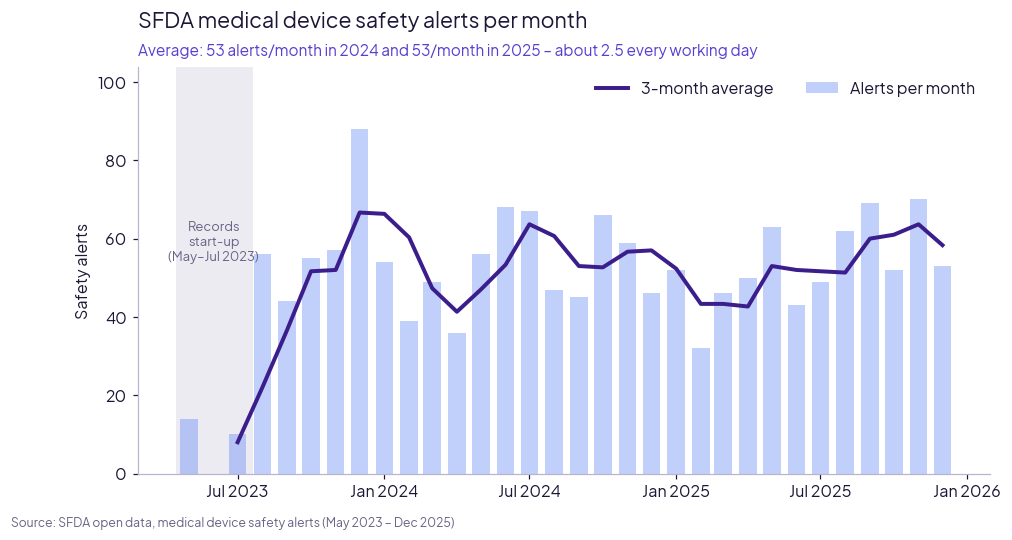


Busiest month: Dec 2023 - 88 alerts
Quietest month: Jun 2023 - 0 alerts


In [10]:
# 4.1 Chart theme, save helper, and alerts per month
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager
import urllib.request

FIG = f'{BASE}/figures'
os.makedirs(FIG, exist_ok=True)

# Expo theme font (Plus Jakarta Sans); falls back to the default font if download fails
try:
    font_path = '/content/PlusJakartaSans.ttf'
    urllib.request.urlretrieve('https://github.com/google/fonts/raw/main/ofl/plusjakartasans/PlusJakartaSans%5Bwght%5D.ttf', font_path)
    font_manager.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
except Exception:
    print('Theme font not loaded, using default font')

PURPLE, VIOLET, BLUE, PINK = '#3B1E8C', '#5B3FD0', '#4C7BF5', '#D6336C'
GREY, INK = '#B9B3CF', '#1E1636'
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GREY, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': INK, 'ytick.color': INK, 'axes.titleweight': 'bold',
    'axes.titlesize': 14, 'axes.titlelocation': 'left', 'font.size': 10.5,
    'figure.dpi': 110,
})

def save_fig(fig, name, source='Source: SFDA open data, medical device safety alerts (May 2023 – Dec 2025)'):
    fig.text(0.01, 0.005, source, fontsize=8, color='#6B6485', ha='left', va='bottom')
    fig.savefig(f'{FIG}/{name}.png', dpi=200, bbox_inches='tight', facecolor='white')
    print('Saved figures/' + name + '.png')

# Chart 4.1 – alerts per month with a 3-month rolling average
alerts['alert_date'] = pd.to_datetime(alerts['alert_date'])
monthly = alerts.set_index('alert_date').resample('MS').size()
rolling = monthly.rolling(3).mean()

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.axvspan(pd.Timestamp('2023-04-15'), pd.Timestamp('2023-07-20'), color=GREY, alpha=0.25, lw=0)
ax.text(pd.Timestamp('2023-06-01'), monthly.max() * 0.62, 'Records\nstart-up\n(May–Jul 2023)',
        ha='center', fontsize=8.5, color='#6B6485')
ax.bar(monthly.index, monthly.values, width=22, color=BLUE, alpha=0.35, label='Alerts per month')
ax.plot(rolling.index, rolling.values, color=PURPLE, linewidth=2.6, label='3-month average')
ax.set_ylim(0, monthly.max() * 1.18)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylabel('Safety alerts')
ax.set_title('SFDA medical device safety alerts per month', pad=26)
avg24, avg25 = monthly['2024'].mean(), monthly['2025'].mean()
ax.text(0, 1.03, f'Average: {avg24:.0f} alerts/month in 2024 and {avg25:.0f}/month in 2025 – about 2.5 every working day',
        transform=ax.transAxes, fontsize=10, color=VIOLET)
ax.legend(frameon=False, loc='upper right', ncol=2)
save_fig(fig, '04_1_alerts_per_month')
plt.show()

print('\nBusiest month:', monthly.idxmax().strftime('%b %Y'), '-', monthly.max(), 'alerts')
print('Quietest month:', monthly.idxmin().strftime('%b %Y'), '-', monthly.min(), 'alerts')

## Step 4.2 – What goes wrong: cause categories

The cause categories from Steps 3.1–3.3, largest first.

- **Pink** = incorrect test result (IVD), the focus of this project.
- **Grey, below the dashed line** = alerts that couldn't be coded ("Other") or whose cause is only in the attached field safety notice. They're shown rather than hidden, so the reader can see how much of the data is uncoded.
- Percentages are of all 1,597 alerts.

**Why it matters:** the single largest cause isn't a broken device but a **wrong lab result**. That failure is invisible: the analyser keeps running and the error only shows up as a clinical decision based on a wrong number. For a distributor of lab analysers and reagents, these alerts call for fast lot tracing and contact with the lab.

Saved figures/04_2_cause_categories.png


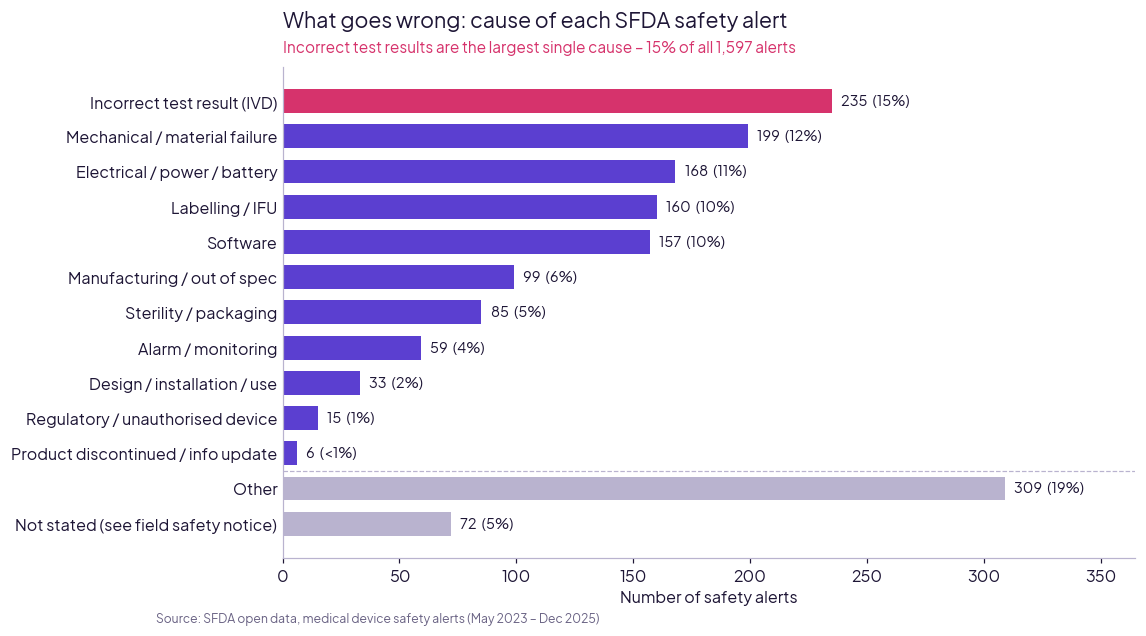

Top 3 causes: Incorrect test result (IVD) (235), Mechanical / material failure (199), Electrical / power / battery (168)
Uncoded (Other + Not stated): 381 (24%)


In [11]:
# 4.2 Cause categories – horizontal bar chart
counts = alerts['cause_category'].value_counts()
uncoded = ['Not stated (see field safety notice)', 'Other']
coded_order = counts.drop(uncoded).sort_values().index.tolist()
counts = counts.reindex(uncoded + coded_order)     # barh draws bottom-up: uncoded at the bottom, biggest cause on top
colours = [GREY if c in uncoded else PINK if c == 'Incorrect test result (IVD)' else VIOLET for c in counts.index]

fig, ax = plt.subplots(figsize=(10, 5.8))
bars = ax.barh(counts.index, counts.values, color=colours, height=0.68)
total = len(alerts)
for bar, v in zip(bars, counts.values):
    label = f'{v}  ({v / total * 100:.0f}%)' if v / total >= 0.005 else f'{v}  (<1%)'
    ax.text(v + 4, bar.get_y() + bar.get_height() / 2, label, va='center', fontsize=9.5)
ax.axhline(1.5, color=GREY, linewidth=0.8, linestyle='--')
ax.set_xlim(0, counts.max() * 1.18)
ax.set_xlabel('Number of safety alerts')
ax.tick_params(axis='y', length=0)
ax.set_title('What goes wrong: cause of each SFDA safety alert', pad=26)
ax.text(0, 1.03, f'Incorrect test results are the largest single cause – '
                 f'{counts["Incorrect test result (IVD)"] / total * 100:.0f}% of all {total:,} alerts',
        transform=ax.transAxes, fontsize=10, color=PINK)
save_fig(fig, '04_2_cause_categories')
plt.show()

coded = counts.drop(uncoded)
print('Top 3 causes:', ', '.join(f'{c} ({v})' for c, v in coded.sort_values(ascending=False).head(3).items()))
print('Uncoded (Other + Not stated):', counts[uncoded].sum(), f'({counts[uncoded].sum() / total * 100:.0f}%)')

## Step 4.3 – What the manufacturer asked for, and the local work it creates

Corrective action types from Steps 3.4–3.6, ordered from **most to least serious** rather than by count.

The grey note beside each bar is the work that action type creates for a Saudi distributor or authorised representative:

- **Removal / recall** → trace every lot or serial number to hospitals, quarantine, collect, reconcile (SFDA MDS-REQ 9 traceability records).
- **On-site correction** → book an engineer visit at every affected site and record completion.
- **Advisory only** → still requires sending the notice and collecting signed acknowledgements from each customer, which is the evidence SFDA can ask for.

**Why it matters:** more than half of alerts (57%) need a physical or product change, not just a letter. About 1 in 5 requires a removal, which is the most time-critical work under SFDA's field safety corrective action (FSCA) deadlines.

Saved figures/04_3_action_types.png


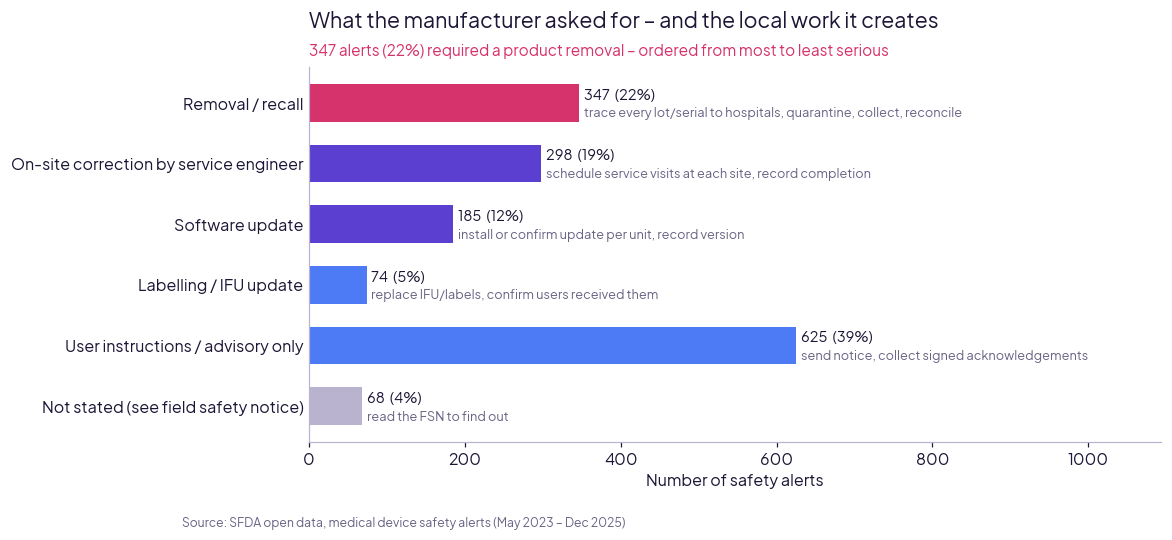

Removals: 347 (22%)
Needing a physical or product change (removal, engineer, software, IFU): 904 (57%)


In [12]:
# 4.3 Corrective action types, ordered by seriousness, with the local work each one creates
severity = ['Removal / recall', 'On-site correction by service engineer', 'Software update',
            'Labelling / IFU update', 'User instructions / advisory only', 'Not stated (see field safety notice)']
local_work = {
    'Removal / recall': 'trace every lot/serial to hospitals, quarantine, collect, reconcile',
    'On-site correction by service engineer': 'schedule service visits at each site, record completion',
    'Software update': 'install or confirm update per unit, record version',
    'Labelling / IFU update': 'replace IFU/labels, confirm users received them',
    'User instructions / advisory only': 'send notice, collect signed acknowledgements',
    'Not stated (see field safety notice)': 'read the FSN to find out',
}
acts = alerts['action_type'].value_counts().reindex(severity[::-1])   # bottom-up, so most serious ends on top
colours = [GREY, BLUE, BLUE, VIOLET, VIOLET, PINK]

fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.barh(acts.index, acts.values, color=colours, height=0.62)
for bar, (name, v) in zip(bars, acts.items()):
    y = bar.get_y() + bar.get_height() / 2
    ax.text(v + 6, y + 0.13, f'{v}  ({v / total * 100:.0f}%)', va='center', fontsize=9.5, fontweight='bold')
    ax.text(v + 6, y - 0.17, local_work[name], va='center', fontsize=8.3, color='#6B6485')
ax.set_xlim(0, acts.max() * 1.75)
ax.set_xlabel('Number of safety alerts')
ax.tick_params(axis='y', length=0)
ax.set_title('What the manufacturer asked for – and the local work it creates', pad=26)
ax.text(0, 1.03, f'{acts["Removal / recall"]} alerts ({acts["Removal / recall"] / total * 100:.0f}%) required a product removal – '
                 f'ordered from most to least serious', transform=ax.transAxes, fontsize=10, color=PINK)
fig.subplots_adjust(bottom=0.17)          # room for the source line under the axis label
save_fig(fig, '04_3_action_types')
plt.show()

concrete_n = acts[severity[:4]].sum()
print('Removals:', acts['Removal / recall'], f"({acts['Removal / recall'] / total * 100:.0f}%)")
print('Needing a physical or product change (removal, engineer, software, IFU):', concrete_n, f'({concrete_n / total * 100:.0f}%)')


## Step 4.4 – Which problems end in a removal?

A heatmap of cause (rows) against corrective action (columns).

- **Row %**: of all alerts with a given cause, the share that led to each action. Each row adds up to 100%.
- `n` = number of alerts in each cell. Categories with very few alerts (e.g. Regulatory, n=15) show large percentages from small counts, so the headline only considers causes with **50+ alerts**.
- The **pink box** marks the removal column.
- Uncoded causes ("Other", "Not stated") and alerts with no stated action are left out.

**Patterns worth noting:**
- **Sterility / packaging** most often ends in removal: a broken sterile barrier can't be fixed in the field.
- **Alarm / monitoring** faults are mostly fixed by **software update**.
- **Incorrect test results** split between **removal of the lot** (about a third) and **advisory only** (about half). Advisory usually means "review patient results already reported", which is work for the lab, not just the distributor.

Saved figures/04_4_cause_by_action_heatmap.png


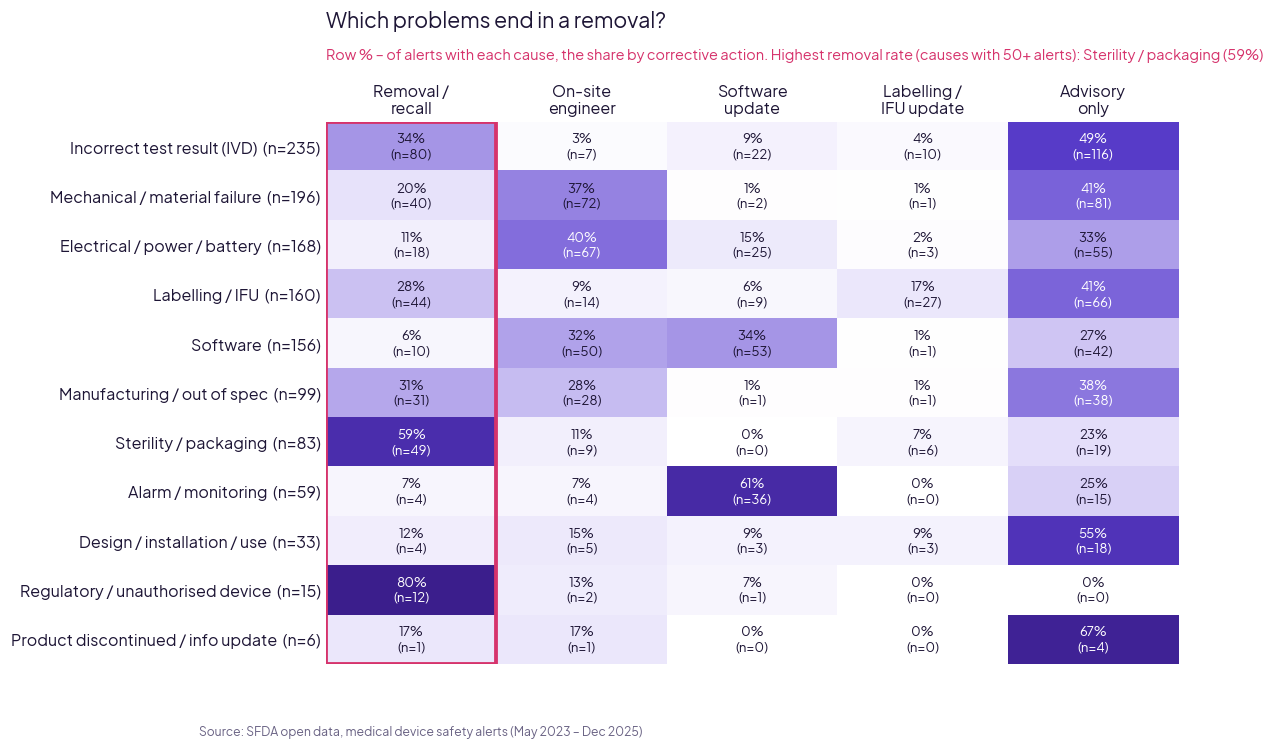

Removal rate by cause (row %):
cause_category
Regulatory / unauthorised device      80%
Sterility / packaging                 59%
Incorrect test result (IVD)           34%
Manufacturing / out of spec           31%
Labelling / IFU                       28%
Mechanical / material failure         20%
Product discontinued / info update    17%
Design / installation / use           12%
Electrical / power / battery          11%
Alarm / monitoring                     7%
Software                               6%


In [13]:
# 4.4 Heatmap: cause x corrective action (row %)
from matplotlib.colors import LinearSegmentedColormap

rows = [c for c in alerts['cause_category'].value_counts().index if c not in uncoded]
cols = severity[:5]                                  # leave out "Not stated" actions
short_cols = ['Removal /\nrecall', 'On-site\nengineer', 'Software\nupdate', 'Labelling /\nIFU update', 'Advisory\nonly']

sub = alerts[alerts['cause_category'].isin(rows) & alerts['action_type'].isin(cols)]
n_table = pd.crosstab(sub['cause_category'], sub['action_type']).reindex(index=rows, columns=cols, fill_value=0)
pct_table = n_table.div(n_table.sum(axis=1), axis=0) * 100           # row %: of alerts with this cause, % per action

cmap = LinearSegmentedColormap.from_list('expo', ['#FFFFFF', '#E4DEFA', VIOLET, PURPLE])
fig, ax = plt.subplots(figsize=(10, 6.4))
ax.imshow(pct_table.values, cmap=cmap, vmin=0, vmax=70, aspect='auto')
for i in range(len(rows)):
    for j in range(len(cols)):
        p, n = pct_table.iat[i, j], n_table.iat[i, j]
        ax.text(j, i, f'{p:.0f}%\n(n={n})', ha='center', va='center', fontsize=8.6,
                color='white' if p >= 38 else INK)
ax.add_patch(plt.Rectangle((-0.5, -0.5), 1, len(rows), fill=False, edgecolor=PINK, linewidth=2.5))
ax.set_xticks(range(len(cols)), short_cols)
ax.set_yticks(range(len(rows)), [f'{r}  (n={n_table.loc[r].sum()})' for r in rows])
ax.xaxis.tick_top()
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)

top_removal = pct_table['Removal / recall'].sort_values(ascending=False)
big = top_removal[n_table.sum(axis=1)[top_removal.index] >= 50]      # ignore causes with fewer than 50 alerts
ax.set_title('Which problems end in a removal?', pad=62)
ax.text(0, 1.115, f'Row % – of alerts with each cause, the share by corrective action. '
                  f'Highest removal rate (causes with 50+ alerts): {big.index[0]} ({big.iloc[0]:.0f}%)',
        transform=ax.transAxes, fontsize=9.5, color=PINK)
save_fig(fig, '04_4_cause_by_action_heatmap')
plt.show()

print('Removal rate by cause (row %):')
print(top_removal.round(0).astype(int).astype(str).add('%').to_string())

## Step 4.5 – How lab (IVD) product alerts differ from other devices

Two panels comparing IVD and non-IVD alerts. Both show **% within each group**, because the groups are different sizes (371 vs 1,226).

- **Left – cause:** 58% of IVD alerts are about incorrect results, versus mechanical, electrical and software faults for other devices.
- **Right – corrective action:** IVD alerts are more often **advisory** (48% vs 36%) and **removal** (26% vs 20%), and rarely need an **engineer visit** (6% vs 23%).

**What this means for an IVD distributor:** the PMS workload is lot tracing and customer communication, not field service. Advisory IVD notices usually ask the lab to **review patient results already reported**, so the distributor has to make sure each lab actually received and acted on the notice.

**Caveat:** the IVD tag (Step 3.7) and the "incorrect test result" cause (Step 3.3) share some keywords (e.g. "reagent", "assay"), so part of the 58% overlap is built in. The action comparison on the right doesn't have this problem.

Saved figures/04_5_ivd_vs_non_ivd.png


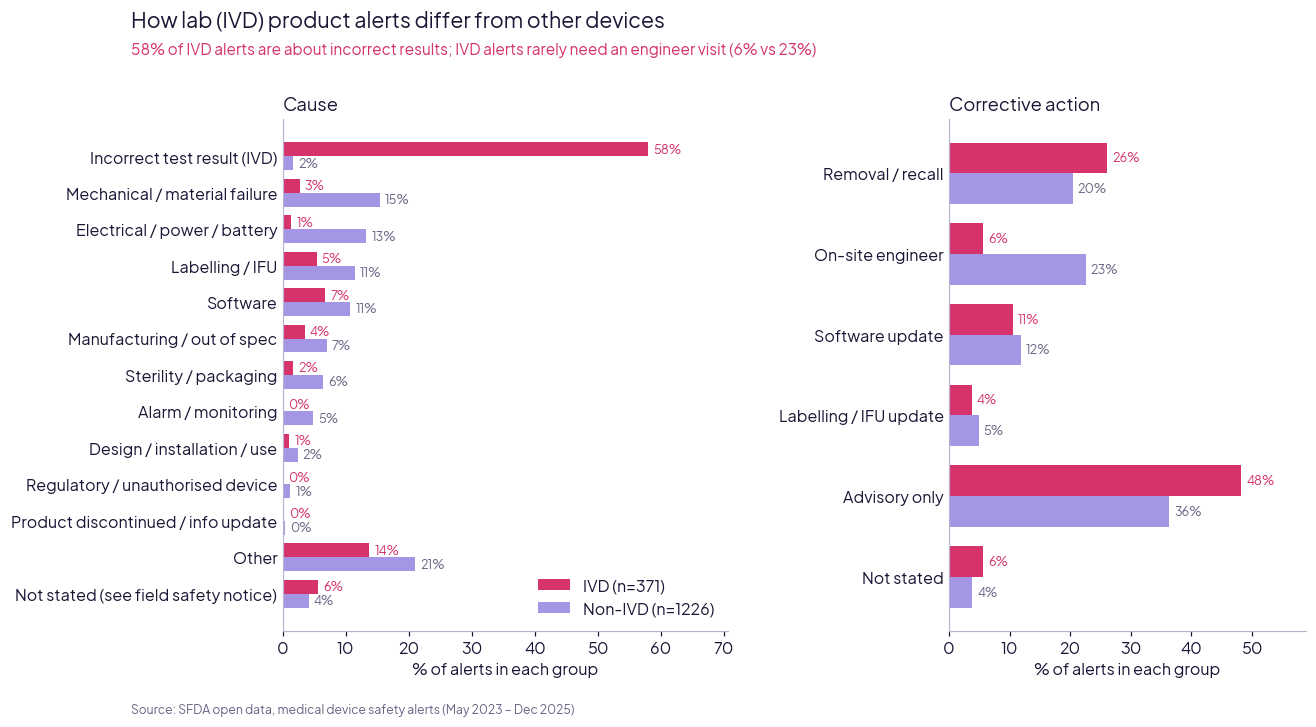

                       IVD %  Non-IVD %
Incorrect test result     58          2
Removal / recall          26         20
Advisory only             48         36
On-site engineer           6         23


In [14]:
# 4.5 IVD vs non-IVD: cause and corrective action, % within each group
import numpy as np
group = alerts['is_ivd'].map({True: 'IVD', False: 'Non-IVD'})
n_ivd, n_non = (group == 'IVD').sum(), (group == 'Non-IVD').sum()

cause_pct = pd.crosstab(alerts['cause_category'], group, normalize='columns') * 100
cause_pct = cause_pct.reindex(uncoded + coded_order)           # same order as chart 4.2
action_pct = pd.crosstab(alerts['action_type'], group, normalize='columns') * 100
action_pct = action_pct.reindex(severity[::-1])
short_actions = ['Not stated', 'Advisory only', 'Labelling / IFU update', 'Software update', 'On-site engineer', 'Removal / recall']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6.2), gridspec_kw={'width_ratios': [1.25, 1], 'wspace': 0.55})
for ax, table, labels, title in [(ax1, cause_pct, cause_pct.index, 'Cause'),
                                 (ax2, action_pct, short_actions, 'Corrective action')]:
    y = np.arange(len(table))
    ax.barh(y + 0.19, table['IVD'], height=0.38, color=PINK, label=f'IVD (n={n_ivd})')
    ax.barh(y - 0.19, table['Non-IVD'], height=0.38, color=VIOLET, alpha=0.55, label=f'Non-IVD (n={n_non})')
    for yi, (a, b) in enumerate(zip(table['IVD'], table['Non-IVD'])):
        ax.text(a + 0.8, yi + 0.19, f'{a:.0f}%', va='center', fontsize=8.3, color=PINK, fontweight='bold')
        ax.text(b + 0.8, yi - 0.19, f'{b:.0f}%', va='center', fontsize=8.3, color='#6B6485')
    ax.set_yticks(y, labels)
    ax.tick_params(axis='y', length=0)
    ax.set_xlim(0, table.values.max() * 1.22)
    ax.set_xlabel('% of alerts in each group')
    ax.set_title(title, fontsize=12, loc='left')
ax1.legend(frameon=False, loc='lower right')

fig.suptitle('How lab (IVD) product alerts differ from other devices', x=0.01, ha='left',
             fontsize=14, fontweight='bold', y=1.04)
ivd_wrong = cause_pct.loc['Incorrect test result (IVD)', 'IVD']
eng = action_pct.loc['On-site correction by service engineer']
fig.text(0.01, 0.975, f'{ivd_wrong:.0f}% of IVD alerts are about incorrect results; IVD alerts rarely need an engineer visit '
                      f'({eng["IVD"]:.0f}% vs {eng["Non-IVD"]:.0f}%)', fontsize=10, color=PINK, ha='left')
fig.subplots_adjust(bottom=0.13)
save_fig(fig, '04_5_ivd_vs_non_ivd')
plt.show()

summary = pd.DataFrame({
    'IVD %':     [ivd_wrong] + [action_pct.loc[a, 'IVD'] for a in ['Removal / recall', 'User instructions / advisory only', 'On-site correction by service engineer']],
    'Non-IVD %': [cause_pct.loc['Incorrect test result (IVD)', 'Non-IVD']] + [action_pct.loc[a, 'Non-IVD'] for a in ['Removal / recall', 'User instructions / advisory only', 'On-site correction by service engineer']],
}, index=['Incorrect test result', 'Removal / recall', 'Advisory only', 'On-site engineer']).round(0).astype(int)
print(summary)

## Step 4.6 – Does the alert say what could happen to the patient?

The harm grades from Step 3.8, shown as 100% stacked bars for IVD alerts, non-IVD alerts and all alerts.

- **Pink / purple / blue** = the manufacturer described the harm (High, Moderate, or Low/none reported).
- **Light grey** = the alert describes the fault but says **nothing about the effect on the patient**.

**The gap:** 90% of IVD alerts don't state the patient harm, versus 74% for other devices. An IVD alert says "potassium results may be falsely low", but the clinical meaning (a missed hyperkalaemia that can cause a cardiac arrhythmia) is left to the reader.

**Next step (future work):** a clinician grading the harm the manufacturers didn't state, so a QA team could prioritise IVD alerts by patient risk rather than in the order they arrive.

Saved figures/04_6_harm_stated_gap.png


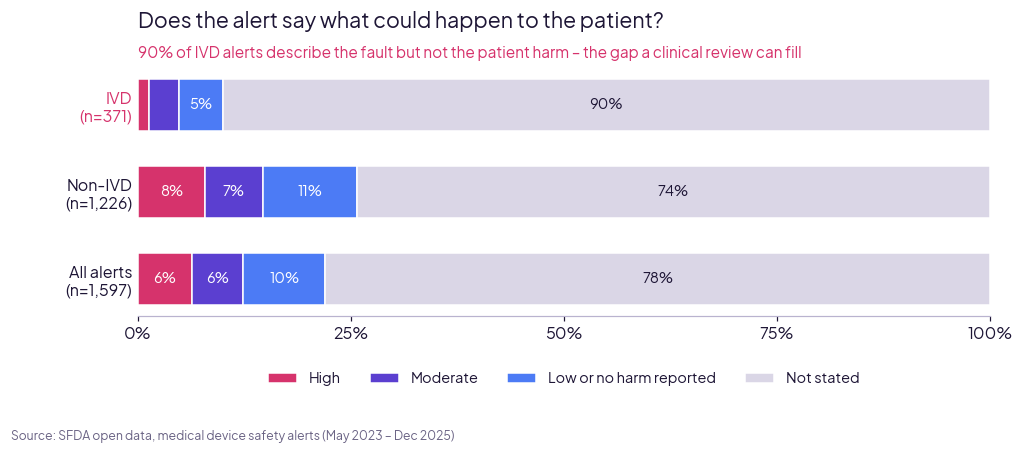

harm_grade  High  Moderate  Low or no harm reported  Not stated
is_ivd                                                         
All alerts     6         6                       10          78
Non-IVD        8         7                       11          74
IVD            1         4                        5          90


In [15]:
# 4.6 Harm stated vs not stated – 100% stacked bars
order = ['High', 'Moderate', 'Low or no harm reported', 'Not stated']
harm_colours = {'High': PINK, 'Moderate': VIOLET, 'Low or no harm reported': BLUE, 'Not stated': '#DAD6E6'}

harm_pct = pd.crosstab(group, alerts['harm_grade'], normalize='index')[order] * 100
harm_pct.loc['All alerts'] = alerts['harm_grade'].value_counts(normalize=True)[order] * 100
harm_pct = harm_pct.reindex(['All alerts', 'Non-IVD', 'IVD'])          # IVD drawn on top
sizes = {'All alerts': total, 'Non-IVD': n_non, 'IVD': n_ivd}

fig, ax = plt.subplots(figsize=(10, 3.9))
left = np.zeros(len(harm_pct))
for grade in order:
    vals = harm_pct[grade].values
    ax.barh(range(len(harm_pct)), vals, left=left, color=harm_colours[grade], height=0.6, label=grade,
            edgecolor='white', linewidth=1)
    for i, (l, v) in enumerate(zip(left, vals)):
        if v >= 4:
            ax.text(l + v / 2, i, f'{v:.0f}%', ha='center', va='center', fontsize=9.5,
                    color=INK if grade == 'Not stated' else 'white', fontweight='bold')
    left += vals
ax.set_yticks(range(len(harm_pct)), [f'{g}\n(n={sizes[g]:,})' for g in harm_pct.index])
ax.get_yticklabels()[2].set_color(PINK)
ax.get_yticklabels()[2].set_fontweight('bold')
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
ax.tick_params(axis='y', length=0)
ax.spines['left'].set_visible(False)
ax.legend(frameon=False, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.17), fontsize=9.5)

not_stated_ivd = harm_pct.loc['IVD', 'Not stated']
ax.set_title('Does the alert say what could happen to the patient?', pad=26)
ax.text(0, 1.04, f'{not_stated_ivd:.0f}% of IVD alerts describe the fault but not the patient harm – '
                 f'the gap a clinical review can fill', transform=ax.transAxes, fontsize=10, color=PINK)
fig.subplots_adjust(bottom=0.3)
save_fig(fig, '04_6_harm_stated_gap')
plt.show()

print(harm_pct.round(0).astype(int))

## Step 4.8 – Top 10 manufacturers

Lead-in to the manufacturer scorecard (Section 5).

- **Left – number of alerts**, with the share that required a removal. Pink = mostly IVD alerts.
- **Right – typical alert size**: the **median** number of units affected per alert, on a log scale.
  - The median is used because a few alerts are huge (the largest covers 28.7 million units, probably single-use consumables), which would make an average meaningless.

**Important caveat – these are counts, not failure rates.** SFDA doesn't publish how many devices each company has in the Saudi market. Philips has the most alerts, probably because it has a very large installed base of imaging and monitoring equipment, not because its devices fail more often. A real comparison needs sales or installed-base data as the denominator, which a distributor has and public data does not.

**Notable:** Philips issues many alerts but almost never removes products (1%), and mostly fixes them on site. The IVD companies Beckman Coulter (31%) and Ortho (38%) remove products far more often, usually reagent lots.

Saved figures/04_8_top10_manufacturers.png


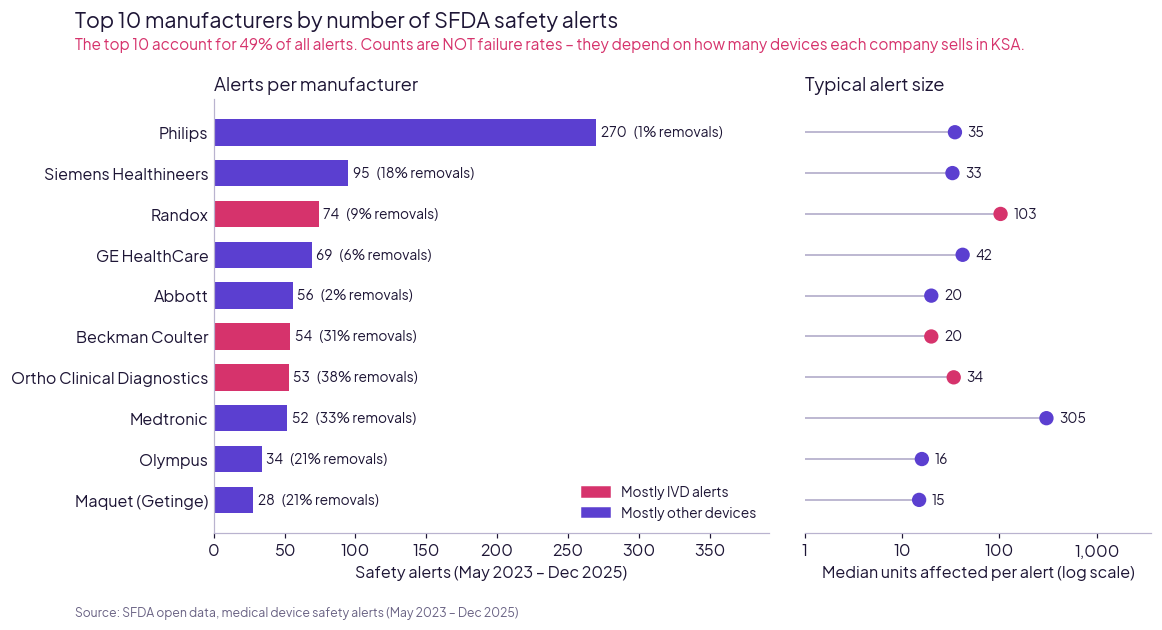

                            alerts ivd_share removal_share  median_units
manufacturer_std                                                        
Philips                        270        0%            1%          35.0
Siemens Healthineers            95       39%           18%          33.0
Randox                          74      100%            9%         103.0
GE HealthCare                   69        3%            6%          42.0
Abbott                          56       41%            2%          20.0
Beckman Coulter                 54      100%           31%          20.0
Ortho Clinical Diagnostics      53      100%           38%          34.0
Medtronic                       52        0%           33%         305.0
Olympus                         34        3%           21%          16.0
Maquet (Getinge)                28        7%           21%          15.0

Top 10 share of all alerts: 49%


In [16]:
# 4.8 Top 10 manufacturers: alert count, removal share, and median units affected
alerts['affected_units'] = pd.to_numeric(alerts['affected_units'], errors='coerce')
top = (alerts.groupby(mfr_col)
             .agg(alerts=('alert_id', 'size'),
                  ivd_share=('is_ivd', 'mean'),
                  removal_share=('action_type', lambda s: (s == 'Removal / recall').mean()),
                  median_units=('affected_units', 'median'))
             .sort_values('alerts', ascending=False).head(10))
top_plot = top.iloc[::-1]                                   # biggest on top
bar_colours = [PINK if s >= 0.5 else VIOLET for s in top_plot['ivd_share']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.4), sharey=True,
                               gridspec_kw={'width_ratios': [1.6, 1], 'wspace': 0.08})
ax1.barh(top_plot.index, top_plot['alerts'], color=bar_colours, height=0.65)
for i, (n, r) in enumerate(zip(top_plot['alerts'], top_plot['removal_share'])):
    ax1.text(n + 3, i, f'{n}   ({r * 100:.0f}% removals)', va='center', fontsize=9)
ax1.set_xlim(0, top_plot['alerts'].max() * 1.45)
ax1.set_xlabel('Safety alerts (May 2023 – Dec 2025)')
ax1.tick_params(axis='y', length=0)
ax1.set_title('Alerts per manufacturer', fontsize=12, loc='left')

ax2.scatter(top_plot['median_units'], range(len(top_plot)), s=70, color=bar_colours, zorder=3)
for i, m in enumerate(top_plot['median_units']):
    ax2.hlines(i, 1, m, color=GREY, linewidth=1.2)
    ax2.text(m * 1.35, i, f'{m:,.0f}', va='center', fontsize=9)
ax2.set_xscale('log')
ax2.set_xlim(1, top_plot['median_units'].max() * 12)
ax2.set_xticks([1, 10, 100, 1000], ['1', '10', '100', '1,000'])
ax2.minorticks_off()
ax2.set_xlabel('Median units affected per alert (log scale)')
ax2.tick_params(axis='y', length=0)
ax2.spines['left'].set_visible(False)
ax2.set_title('Typical alert size', fontsize=12, loc='left')

from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color=PINK, label='Mostly IVD alerts'), Patch(color=VIOLET, label='Mostly other devices')],
           frameon=False, loc='lower right', fontsize=9)
fig.suptitle('Top 10 manufacturers by number of SFDA safety alerts', x=0.01, ha='left',
             fontsize=14, fontweight='bold', y=1.03)
fig.text(0.01, 0.965, f'The top 10 account for {top["alerts"].sum() / total * 100:.0f}% of all alerts. '
                      'Counts are NOT failure rates – they depend on how many devices each company sells in KSA.',
         fontsize=10, color=PINK, ha='left')
fig.subplots_adjust(bottom=0.15)
save_fig(fig, '04_8_top10_manufacturers')
plt.show()

print(top.assign(ivd_share=(top['ivd_share'] * 100).round(0).astype(int).astype(str) + '%',
                 removal_share=(top['removal_share'] * 100).round(0).astype(int).astype(str) + '%',
                 median_units=top['median_units'].round(0)))
print('\nTop 10 share of all alerts:', f'{top["alerts"].sum() / total * 100:.0f}%')

# Section 5 – Manufacturer scorecard (supplier monitoring)

For a Saudi distributor or authorised representative, the **manufacturer is the supplier**. ISO 13485 clause 7.4 requires suppliers to be evaluated and **monitored**, and SFDA safety alerts are a public, independent record of supplier performance after the device reaches the market.

## Step 5.1 – Build the scorecard table

One row per manufacturer with **10 or more alerts** (fewer is too little to read a pattern from).

| Column | Meaning | Why a QA manager cares |
|---|---|---|
| `alerts` | Total alerts, May 2023 – Dec 2025 | Volume of PMS work this supplier creates |
| `alerts_per_year` | Average over the full years 2024–2025 | Comparable yearly workload |
| `ivd_pct` | % of alerts that are IVD | Lab products vs devices |
| `removal_pct` | % ending in a product removal | Most demanding local action (lot tracing, quarantine) |
| `high_harm_pct` | % where the manufacturer states death / serious harm | Severity of the issues |
| `fsn_only_pct` | % where cause or action is only "see attached FSN" | **Quality of the supplier's communication**: the QA team has to dig into the PDF to know what to do |
| `median_units` | Median units affected per alert | Typical size of each alert |
| `top_cause` | Most common coded cause | Where the supplier's problems usually come from |

**Caveats:**
- These are **monitoring signals, not a ranking of device quality**. With no sales or installed-base data, more alerts can simply mean more devices on the market.
- Subsidiaries are kept as named in the alerts (e.g. Covidien is shown separately from Medtronic, Datex-Ohmeda from GE).

In [17]:
# 5.1 Manufacturer scorecard – one row per manufacturer with 10+ alerts
MIN_ALERTS = 10
alerts['fsn_only'] = (alerts['cause_category'] == 'Not stated (see field safety notice)') | \
                     (alerts['action_type'] == 'Not stated (see field safety notice)')
full_years = alerts[alerts['alert_date'].dt.year.isin([2024, 2025])]

def top_coded_cause(s):
    coded = s[~s.isin(uncoded)]
    return coded.mode().iat[0] if len(coded) else 'Uncoded'

scorecard = (alerts.groupby(mfr_col)
                   .agg(alerts=('alert_id', 'size'),
                        ivd_pct=('is_ivd', 'mean'),
                        removal_pct=('action_type', lambda s: (s == 'Removal / recall').mean()),
                        high_harm_pct=('harm_grade', lambda s: (s == 'High').mean()),
                        fsn_only_pct=('fsn_only', 'mean'),
                        median_units=('affected_units', 'median'),
                        top_cause=('cause_category', top_coded_cause),
                        last_alert=('alert_date', 'max')))
scorecard['alerts_per_year'] = full_years.groupby(mfr_col).size().reindex(scorecard.index, fill_value=0) / 2
scorecard = scorecard[scorecard['alerts'] >= MIN_ALERTS].sort_values('alerts', ascending=False)
for c in ['ivd_pct', 'removal_pct', 'high_harm_pct', 'fsn_only_pct']:
    scorecard[c] = (scorecard[c] * 100).round(0).astype(int)
scorecard['last_alert'] = scorecard['last_alert'].dt.date

print('Manufacturers with', MIN_ALERTS, '+ alerts:', len(scorecard),
      f'– covering {scorecard["alerts"].sum()} of {total} alerts ({scorecard["alerts"].sum() / total * 100:.0f}%)\n')
pd.set_option('display.width', 200)
print(scorecard.drop(columns=['last_alert']).to_string())

Manufacturers with 10 + alerts: 25 – covering 1006 of 1597 alerts (63%)

                                 alerts  ivd_pct  removal_pct  high_harm_pct  fsn_only_pct  median_units                      top_cause  alerts_per_year
manufacturer_std                                                                                                                                        
Philips                             270        0            1              9             0          35.0  Mechanical / material failure            114.0
Siemens Healthineers                 95       39           18              0             1          33.0    Incorrect test result (IVD)             30.5
Randox                               74      100            9              0             0         103.0    Incorrect test result (IVD)             30.0
GE HealthCare                        69        3            6             19             0          42.0   Electrical / power / battery             31.5
Abbott   

## Step 5.2 – Monitoring flags and review level

The scorecard numbers become simple yes/no flags, the way a supplier review meeting reads them.

| Flag | Rule | Why it matters |
|---|---|---|
| **Frequent removals** | removal share ≥ 30% | Heavy lot-tracing and quarantine work; check that traceability records are complete |
| **Serious harm stated** | ≥ 20% of alerts state death / serious harm | Severity: these alerts need the fastest response (SFDA 2-day / 10-day reporting) |
| **Communication gap** | ≥ 20% of alerts give the cause or action only as "see attached FSN" | The QA team has to read every PDF to know what to do; raise it with the supplier |
| **High workload** | ≥ 20 alerts a year (2024–2025) | Plan PMS staff time for this supplier |
| **Large alerts** | median ≥ 1,000 units per alert | Each alert affects a lot of stock or many sites |

**Review level:** 0 flags = *Routine*, 1 flag = *Watch*, 2+ flags = *Priority review*.

**Caveats:** the thresholds are my judgment calls and are easy to change in the code. A flag is a reason to look closer at a supplier, not proof of poor quality. The no-denominator caveat from Step 5.1 still applies.

In [18]:
# 5.2 Turn scorecard numbers into monitoring flags and a review level
flag_rules = {
    'Frequent removals':   scorecard['removal_pct'] >= 30,
    'Serious harm stated': scorecard['high_harm_pct'] >= 20,
    'Communication gap':   scorecard['fsn_only_pct'] >= 20,
    'High workload':       scorecard['alerts_per_year'] >= 20,
    'Large alerts':        scorecard['median_units'] >= 1000,
}
flags = pd.DataFrame(flag_rules)
scorecard['flags'] = flags.apply(lambda r: ', '.join(r.index[r]), axis=1)
scorecard['n_flags'] = flags.sum(axis=1)
scorecard['review_level'] = pd.cut(scorecard['n_flags'], bins=[-1, 0, 1, 10],
                                   labels=['Routine', 'Watch', 'Priority review'])

print('How many manufacturers trigger each flag:')
print(flags.sum().to_string())
print('\nReview level:')
print(scorecard['review_level'].value_counts().reindex(['Priority review', 'Watch', 'Routine']).to_string())
print()
print(scorecard.sort_values(['n_flags', 'alerts'], ascending=False)[['alerts', 'review_level', 'flags']].to_string())

How many manufacturers trigger each flag:
Frequent removals      10
Serious harm stated     3
Communication gap       2
High workload           7
Large alerts            3

Review level:
review_level
Priority review     6
Watch              13
Routine             6

                                 alerts     review_level                                   flags
manufacturer_std                                                                                
Abbott                               56  Priority review        Communication gap, High workload
Beckman Coulter                      54  Priority review        Frequent removals, High workload
Medtronic                            52  Priority review        Frequent removals, High workload
Boston Scientific                    18  Priority review  Frequent removals, Serious harm stated
Saudi Mais For Medical Products      10  Priority review         Frequent removals, Large alerts
Welch Allyn                          10  Priority revi

## Step 5.3 – Scorecard visual and export

The full scorecard as one table:

- Rows are sorted by **review level** (Priority review → Watch → Routine), then by number of alerts.
- **Pink cells** are the values that triggered a flag in Step 5.2, so the reader can see *why* a manufacturer is flagged, not just that it is.
- The scorecard is also saved as `data/clean/manufacturer_scorecard.csv` for the Power BI report.

**How a distributor would use it:** in a supplier review or management review (ISO 13485 §5.6), each *Priority review* manufacturer gets a specific question. For example:
- **Abbott:** "Can field safety notices include the cause and action in the notification itself, not only in the attached PDF?"
- **Beckman Coulter:** "Our traceability records must support frequent reagent lot removals. Are they complete?"

Saved figures/05_3_manufacturer_scorecard.png


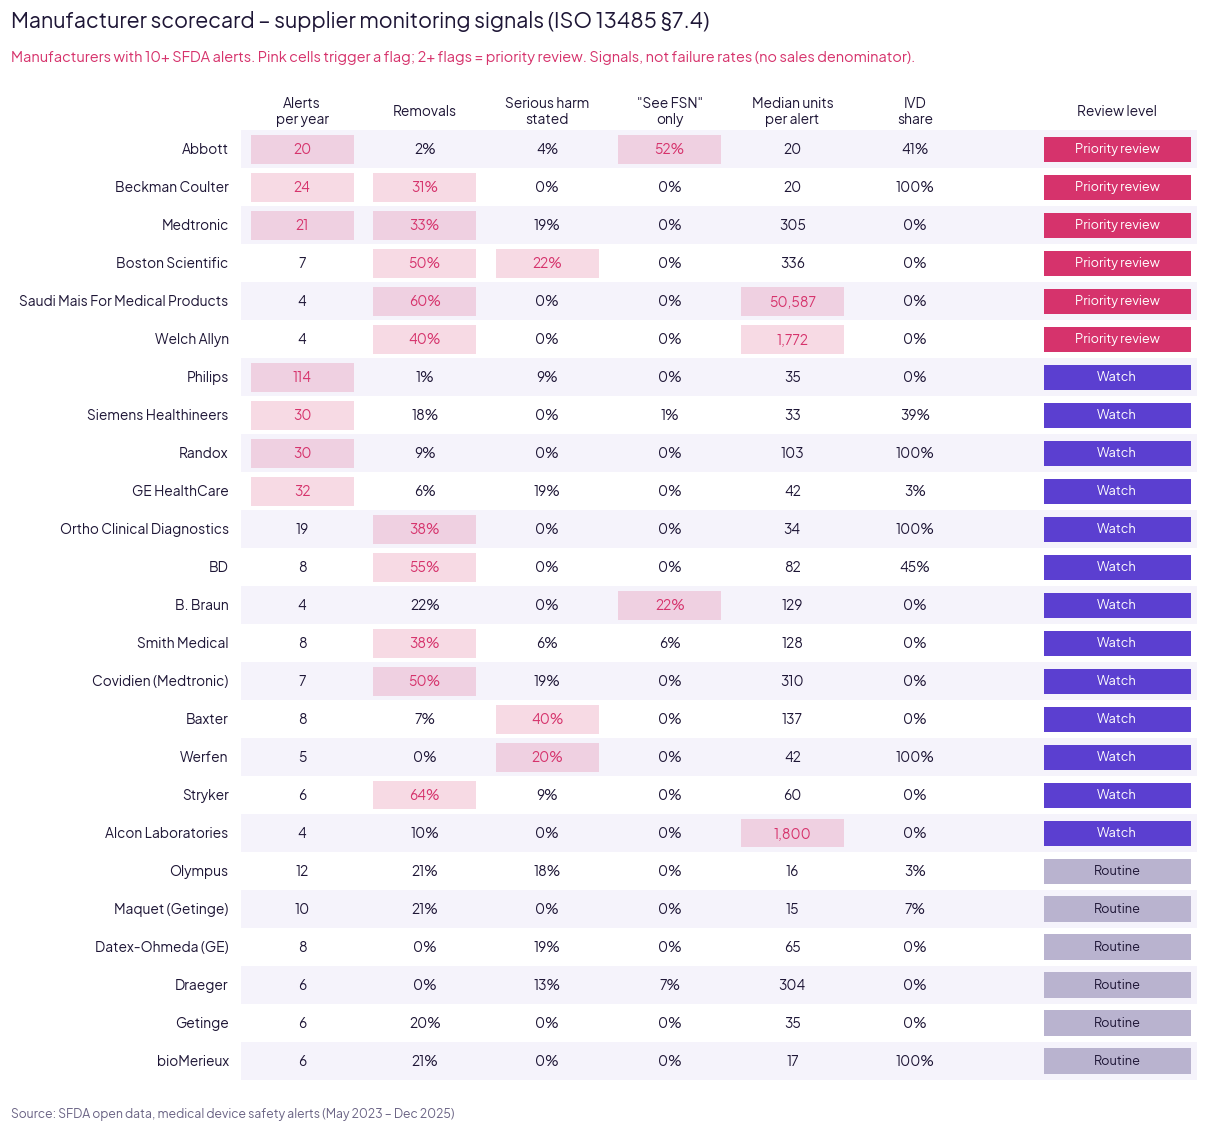

Saved data/clean/manufacturer_scorecard.csv with 25 manufacturers and 13 columns


In [19]:
# 5.3 Scorecard visual (flagged cells in pink) and CSV export
level_order = {'Priority review': 0, 'Watch': 1, 'Routine': 2}
sc = scorecard.assign(_lvl=scorecard['review_level'].map(level_order).astype(int)) \
              .sort_values(['_lvl', 'alerts'], ascending=[True, False])

cols = [('alerts_per_year', 'Alerts\nper year', 'High workload', '{:.0f}'),
        ('removal_pct', 'Removals', 'Frequent removals', '{:.0f}%'),
        ('high_harm_pct', 'Serious harm\nstated', 'Serious harm stated', '{:.0f}%'),
        ('fsn_only_pct', '"See FSN"\nonly', 'Communication gap', '{:.0f}%'),
        ('median_units', 'Median units\nper alert', 'Large alerts', '{:,.0f}'),
        ('ivd_pct', 'IVD\nshare', None, '{:.0f}%')]
level_colours = {'Priority review': PINK, 'Watch': VIOLET, 'Routine': GREY}

n = len(sc)
fig, ax = plt.subplots(figsize=(11, 0.36 * n + 1.4))
fig.subplots_adjust(left=0.2, right=0.99, top=0.9, bottom=0.04)
ax.set_xlim(-0.5, len(cols) + 1.3)
ax.set_ylim(n - 0.5, -1.4)
ax.axis('off')
for j, (col, label, flag, fmt) in enumerate(cols):
    ax.text(j, -1.0, label, ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(len(cols) + 0.65, -1.0, 'Review level', ha='center', va='center', fontsize=9, fontweight='bold')

for i, (name, row) in enumerate(sc.iterrows()):
    if i % 2 == 0:
        ax.add_patch(plt.Rectangle((-3.6, i - 0.5), len(cols) + 5.0, 1, color='#F5F3FB', zorder=0, lw=0))
    ax.text(-0.6, i, name, ha='right', va='center', fontsize=9)
    for j, (col, label, flag, fmt) in enumerate(cols):
        flagged = flag is not None and flag in row['flags']
        if flagged:
            ax.add_patch(plt.Rectangle((j - 0.42, i - 0.38), 0.84, 0.76, color=PINK, alpha=0.18, lw=0))
        ax.text(j, i, fmt.format(row[col]), ha='center', va='center', fontsize=9,
                color=PINK if flagged else INK, fontweight='bold' if flagged else 'normal')
    lvl = row['review_level']
    ax.add_patch(plt.Rectangle((len(cols) + 0.05, i - 0.33), 1.2, 0.66, color=level_colours[lvl], lw=0))
    ax.text(len(cols) + 0.65, i, lvl, ha='center', va='center', fontsize=8.3,
            color='white' if lvl != 'Routine' else INK, fontweight='bold')

fig.text(0.01, 0.975, 'Manufacturer scorecard – supplier monitoring signals (ISO 13485 §7.4)',
         fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(0.01, 0.94, 'Manufacturers with 10+ SFDA alerts. Pink cells trigger a flag; 2+ flags = priority review. '
                     'Signals, not failure rates (no sales denominator).', fontsize=9.5, color=PINK, ha='left', va='top')
save_fig(fig, '05_3_manufacturer_scorecard')
plt.show()

# Export for Power BI and the portfolio
out = sc.drop(columns=['_lvl']).reset_index().rename(columns={mfr_col: 'manufacturer'})
out.to_csv(f'{CLEAN}/manufacturer_scorecard.csv', index=False)
print('Saved data/clean/manufacturer_scorecard.csv with', len(out), 'manufacturers and', out.shape[1], 'columns')

# Section 6 – Key findings

## Step 6.1 – What the data shows

**1. Steady workload.** SFDA issues about **53 medical device safety alerts a month**, roughly 2–3 every working day for a QA/PMS team to screen.

**2. Wrong results are the largest single cause.** **15%** of all alerts are about incorrect test results from lab (IVD) products. This failure is invisible: the analyser keeps working and the error only appears as a clinical decision based on a wrong number.

**3. Most alerts create real local work.** **57%** require a physical or product change (removal, engineer visit, software or labelling update), and **22%** require a product removal with full lot tracing.

**4. IVD alerts need a different PMS approach.** IVD alerts rarely need an engineer visit (**6% vs 23%**). The work is lot tracing, customer communication, and making sure labs review the patient results they've already reported.

**5. The patient-harm gap.** **90% of IVD alerts don't say what the fault could mean for the patient** (74% for other devices). A clinical review can close this gap (see Step 3.10).

**6. Supplier monitoring.** Of the **25 manufacturers with 10+ alerts**, **6 meet the Priority review threshold** (2+ flags) and 13 are on Watch (ISO 13485 §7.4). Volume alone misleads: Philips has the most alerts but almost never removes products.

**Limitations:**
- No sales or installed-base data, so these are counts, not failure rates.
- 24% of causes couldn't be coded from the text.
- The codes come from keyword rules checked by spot-checks, not a validated coding system.
- The harm grade reflects what manufacturers wrote, not a full risk assessment (ISO 14971).

In [20]:
# 6.1 Recalculate every headline number from the data (so the README matches the notebook)
ivd = alerts[alerts['is_ivd']]
non_ivd = alerts[~alerts['is_ivd']]
eng = 'On-site correction by service engineer'

facts = {
    'Alerts analysed': f'{total:,} (May 2023 – Dec 2025)',
    'Alerts per month (2024–2025)': f'{monthly["2024":"2025"].mean():.0f}',
    'Largest cause': f'Incorrect test result – {(alerts["cause_category"] == "Incorrect test result (IVD)").mean() * 100:.0f}% of all alerts',
    'Needing a physical/product change': f'{alerts["action_type"].isin(severity[:4]).mean() * 100:.0f}%',
    'Product removals': f'{(alerts["action_type"] == "Removal / recall").mean() * 100:.0f}%',
    'IVD alerts': f'{len(ivd)} ({len(ivd) / total * 100:.0f}%)',
    'IVD alerts needing an engineer visit': f'{(ivd["action_type"] == eng).mean() * 100:.0f}% (vs {(non_ivd["action_type"] == eng).mean() * 100:.0f}% non-IVD)',
    'IVD alerts with no patient harm stated': f'{(ivd["harm_grade"] == "Not stated").mean() * 100:.0f}% (vs {(non_ivd["harm_grade"] == "Not stated").mean() * 100:.0f}% non-IVD)',
    'Top 10 manufacturers share': f'{top["alerts"].sum() / total * 100:.0f}% of alerts',
    'Scorecard (10+ alerts)': f'{len(scorecard)} manufacturers: ' + ', '.join(
        f'{v} {k}' for k, v in scorecard['review_level'].value_counts().reindex(['Priority review', 'Watch', 'Routine']).items()),
    'Uncoded causes (transparency)': f'{alerts["cause_category"].isin(uncoded).mean() * 100:.0f}%',
}
for k, v in facts.items():
    print(f'{k:<40} {v}')

Alerts analysed                          1,597 (May 2023 – Dec 2025)
Alerts per month (2024–2025)             53
Largest cause                            Incorrect test result – 15% of all alerts
Needing a physical/product change        57%
Product removals                         22%
IVD alerts                               371 (23%)
IVD alerts needing an engineer visit     6% (vs 23% non-IVD)
IVD alerts with no patient harm stated   90% (vs 74% non-IVD)
Top 10 manufacturers share               49% of alerts
Scorecard (10+ alerts)                   25 manufacturers: 6 Priority review, 13 Watch, 6 Routine
Uncoded causes (transparency)            24%
